In [1]:
import getdist
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rings2cosmo
from getdist import MCSamples, plots

pd.set_option("display.max_colwidth", None)

%matplotlib inline

In [2]:
mpl.rcParams.update(
    {
        "font.size": 20,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
    }
)

# Data used for plotting and `rings2cosmo` script to obtain gamma_PPN:
colors = plt.cm.turbo(np.linspace(0.1, 0.9, 20))
labels = [r"\alpha", r"\beta", r"\delta", r"\gamma"]

In [3]:
# Loading the data
Data = pd.read_csv("01_LaStBeRu_cosmo_ground.csv")
len(Data)

132

In [4]:
alpha_true = 2
beta_true = 0.18
delta_true = 2.4
gamma_true = 1
nsteps = 15_000  # Number of steps

In [5]:
def get_mcmc(z_L, z_S, theta_E, theta_ap, seeing_atm, velDisp, velDispErr, label):
    sampler = rings2cosmo.logprobability_sampling(
        z_S,
        z_L,
        velDisp,
        velDispErr,
        theta_E,
        seeing_atm,
        theta_ap,
        seed=42,
        alpha_ini=alpha_true,
        beta_ini=beta_true,
        delta_ini=delta_true,
        gamma_ini=gamma_true,
        alpha_0_value=alpha_true,
        eps_alpha_0_value=0.08,
        beta_0_value=beta_true,
        eps_beta_0_value=0.13,
        delta_0_value=delta_true,
        eps_delta_0_value=0.11,
        n_dim=4,
        n_walkers=64,
        n_burn=500,
        n_steps=nsteps,
        progress="notebook",
        processes=64,
    )
    samples = MCSamples(
        samples=sampler.get_chain(discard=500, thin=1, flat=True),
        names=["alpha", "beta", "delta", "gamma"],
        labels=labels,
        label=label,
    )
    # Customized triangle plot
    g = plots.get_subplot_plotter(subplot_size=4)
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.5
    g.settings.title_limit_fontsize = 20
    g.settings.axes_fontsize = 20
    g.settings.axes_labelsize = 20
    g.settings.legend_fontsize = 20
    g.triangle_plot(
        [samples],
        filled=True,
        legend_labels=[label],
        legend_loc="upper right",
        line_args=[{"ls": "--", "color": "black"}],
        contour_colors=["black"],
        title_limit=1,
        markers={
            "alpha": alpha_true,
            "beta": beta_true,
            "delta": delta_true,
            "gamma": gamma_true,
        },
    )
    return samples

<unknown>:9: SyntaxWarning: invalid escape sequence '\m'


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


CPU times: user 4min 35s, sys: 1min 5s, total: 5min 41s
Wall time: 13min 45s


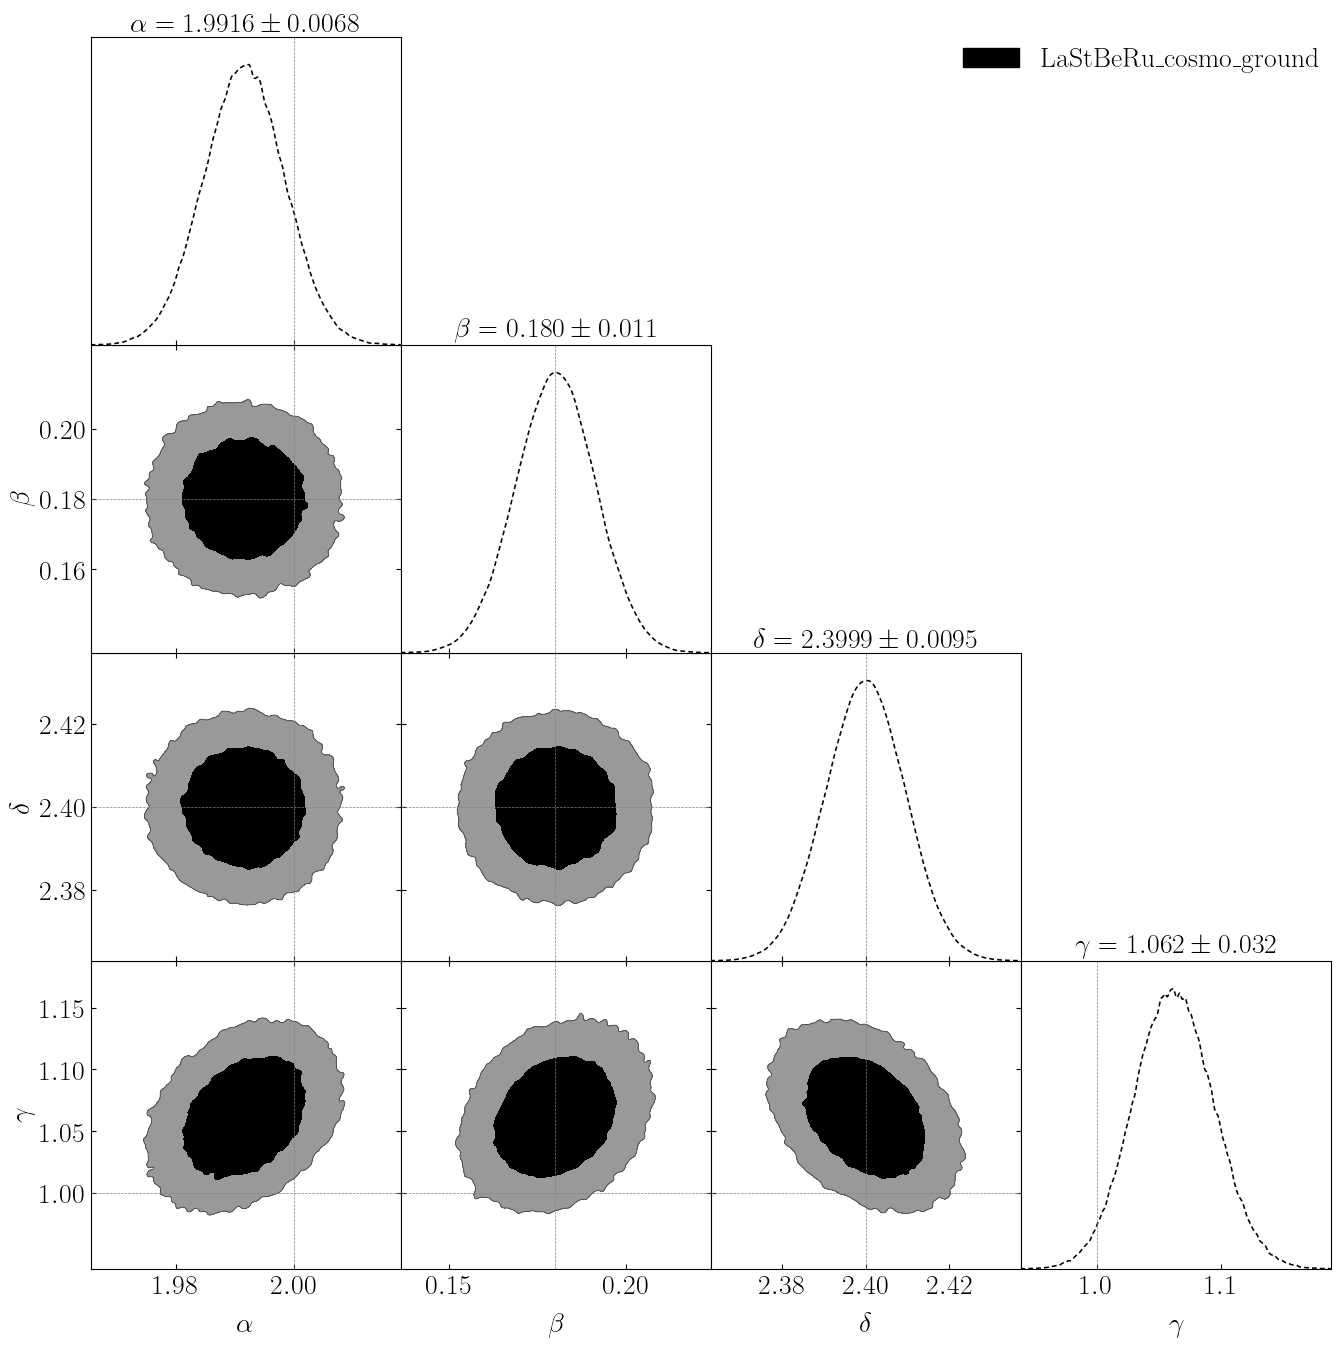

In [6]:
%%time
case_2_3 = get_mcmc(
    z_L=Data["z_L"].values,
    z_S=Data["z_S"].values,
    theta_E=Data["theta_E_rad"].values,
    theta_ap=Data["theta_ap_rad"].values,
    seeing_atm=Data["seeing50_rad"].values,
    velDisp=Data["velDisp0_petro"].values,
    velDispErr=Data["velDisp0Err_petro"].values,
    label="$\mathrm{LaStBeRu\_cosmo\_ground}$",
)

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_633239/2129189087.py:1: SyntaxWarning: invalid escape sequence '\m'
  label = "$\mathrm{LaStBeRu\_cosmo\_ground}$"


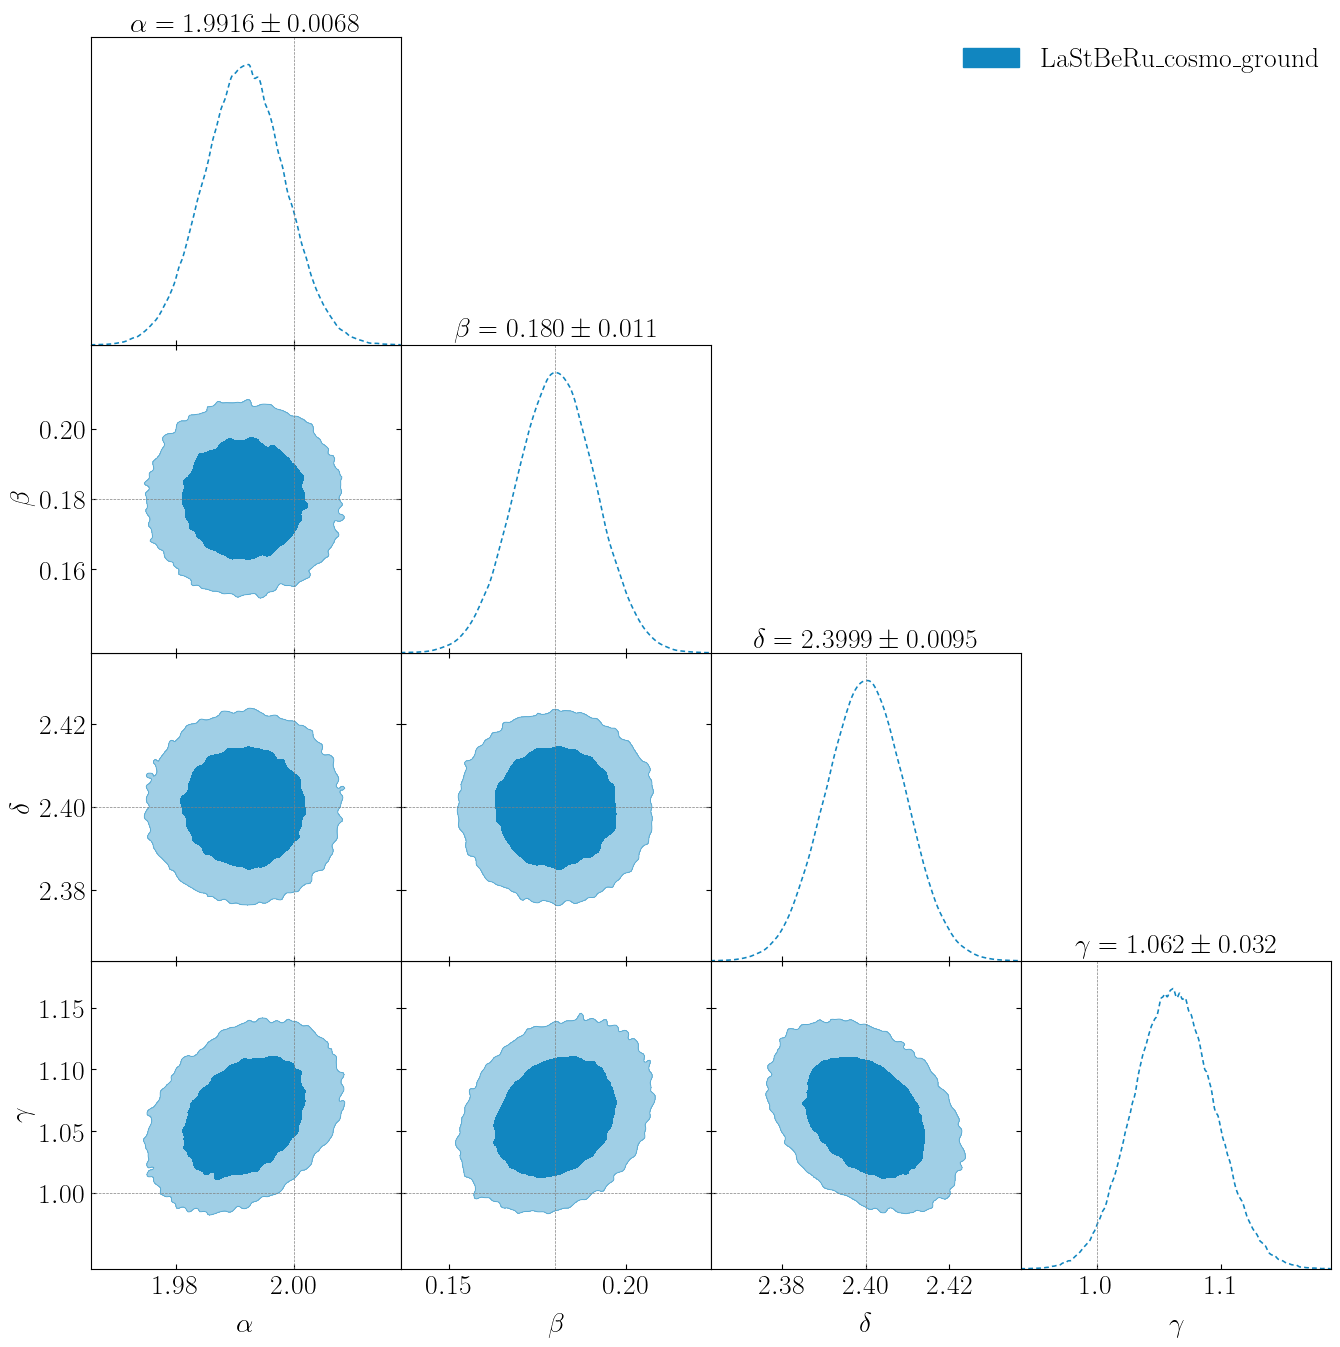

In [7]:
label = "$\mathrm{LaStBeRu\_cosmo\_ground}$"
# Customized triangle plot
g = plots.get_subplot_plotter(subplot_size=4)
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.5
g.settings.title_limit_fontsize = 20
g.settings.axes_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.legend_fontsize = 20
g.triangle_plot(
    [case_2_3],
    filled=True,
    labels=[r"\alpha", r"\beta", r"\delta", r"\gamma_\mathrm{PPN}"],
    legend_labels=[label],
    legend_loc="upper right",
    line_args=[{"ls": "--", "color": "#1186c0"}],
    contour_colors=["#1186c0"],
    title_limit=1,
    markers={
        "alpha": alpha_true,
        "beta": beta_true,
        "delta": delta_true,
        "gamma": gamma_true,
    },
)
# plt.savefig(
#     "graphics/mcmc-example.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

In [8]:
# !convert -trim graphics/mcmc-example.pdf graphics/mcmc-example.pdf